# Telco Customer Churn — Notebook 04: Model Evaluation

**Input:** `telco_churn_cleaned.csv` + trained models from Notebook 03  
**Contains:** Confusion matrix · ROC curve · Precision-Recall curve · Feature importance · Business impact

## 0. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    confusion_matrix, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score
)

# Chart palette — consistent with EDA notebooks
RETAINED = '#2E86AB'
CHURNED  = '#E84855'
ACCENT   = '#F4A261'
BG       = '#F8F9FA'
GREY     = '#6C757D'
COLORS   = [RETAINED, CHURNED, ACCENT]

plt.rcParams.update({
    'font.family'    : 'DejaVu Sans',
    'axes.titlesize' : 13,
    'axes.labelsize' : 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

import os
os.makedirs('../images', exist_ok=True)
print('Setup complete ✅')

Setup complete ✅


## 1. Rebuild Models

Retrain all three models from scratch so this notebook is fully self-contained and runnable independently.

In [2]:
df = pd.read_csv('../data/telco_churn_cleaned.csv')

drop_cols = [
    'customerID', 'Churn', 'Churn_enc', 'tenure_group',
    'SeniorCitizen_enc', 'Partner_enc', 'Dependents_enc',
    'PhoneService_enc', 'PaperlessBilling_enc'
]
X = df.drop(columns=drop_cols)
y = df['Churn_enc']

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols = [c for c in X.columns if c not in num_cols]

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore',
                          sparse_output=False), cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos

# Train all three
lr_pipe = Pipeline([('pre', preprocessor),
                    ('clf', LogisticRegression(class_weight='balanced',
                                               max_iter=1000, random_state=42))])

rf_pipe = Pipeline([('pre', preprocessor),
                    ('clf', RandomForestClassifier(n_estimators=100, max_depth=10,
                                                    class_weight='balanced', random_state=42))])

xgb_pipe = Pipeline([('pre', preprocessor),
                     ('clf', XGBClassifier(n_estimators=100, max_depth=5,
                                            learning_rate=0.1, scale_pos_weight=spw,
                                            eval_metric='logloss', random_state=42,
                                            verbosity=0))])

for pipe, name in [(lr_pipe,'LR'),(rf_pipe,'RF'),(xgb_pipe,'XGB')]:
    pipe.fit(X_train, y_train)
    print(f'{name} trained ✅')

# Collect predictions
models = {
    'Logistic Regression': lr_pipe,
    'Random Forest'      : rf_pipe,
    'XGBoost'            : xgb_pipe,
}

preds  = {n: p.predict(X_test)           for n, p in models.items()}
probas = {n: p.predict_proba(X_test)[:,1] for n, p in models.items()}

LR trained ✅
RF trained ✅
XGB trained ✅


## 2. Confusion Matrix — Best Model (XGBoost)

The confusion matrix shows four outcomes: correctly identified churners (TP), missed churners (FN), incorrectly flagged retained customers (FP), and correctly identified retained customers (TN).

For churn prediction, **false negatives are the most expensive error** — a missed churner means a customer lost without intervention.

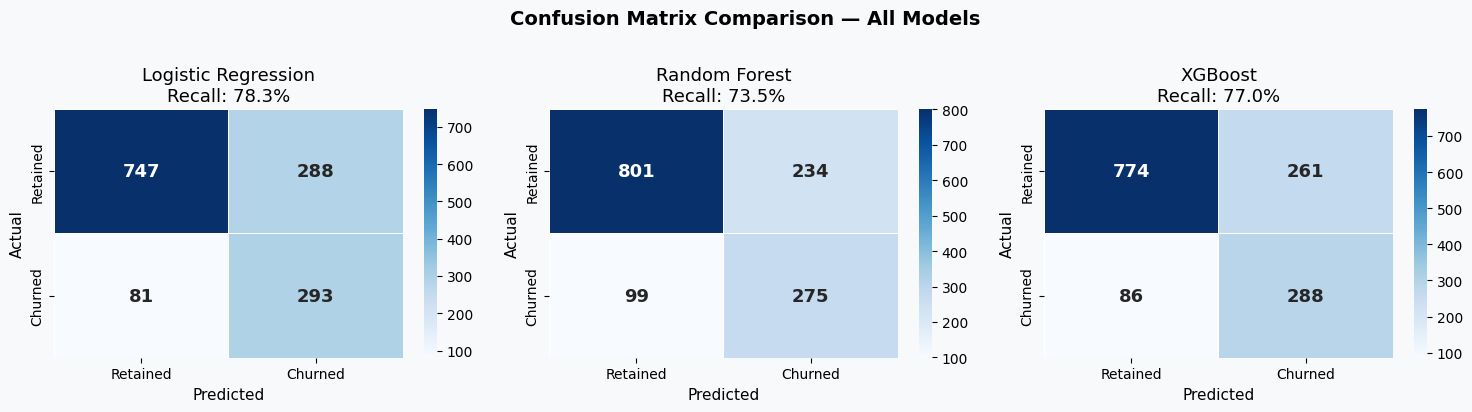


=== XGBoost — Confusion Matrix Breakdown ===
True Positive  (Churned  → predicted Churned)   :  288  ✅ Caught
False Negative (Churned  → predicted Retained)  :   86  ❌ Missed
False Positive (Retained → predicted Churned)   :  261  ⚠  Unnecessary outreach
True Negative  (Retained → predicted Retained)  :  774  ✅ Correct

Churners caught : 288/374 = 77.0%


In [3]:
# ── Confusion matrices for all three models ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.patch.set_facecolor(BG)

for ax, (name, pred), color in zip(axes, preds.items(), COLORS):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Retained','Churned'],
                yticklabels=['Retained','Churned'],
                linewidths=0.5, linecolor='white',
                annot_kws={'size':13,'weight':'bold'}, ax=ax)
    tn, fp, fn, tp = cm.ravel()
    recall = tp/(tp+fn)*100
    ax.set(title=f'{name}\nRecall: {recall:.1f}%',
           xlabel='Predicted', ylabel='Actual')

plt.suptitle('Confusion Matrix Comparison — All Models',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Detailed breakdown for XGBoost
cm_xgb = confusion_matrix(y_test, preds['XGBoost'])
tn, fp, fn, tp = cm_xgb.ravel()
print('\n=== XGBoost — Confusion Matrix Breakdown ===')
print(f'True Positive  (Churned  → predicted Churned)   : {tp:>4}  ✅ Caught')
print(f'False Negative (Churned  → predicted Retained)  : {fn:>4}  ❌ Missed')
print(f'False Positive (Retained → predicted Churned)   : {fp:>4}  ⚠  Unnecessary outreach')
print(f'True Negative  (Retained → predicted Retained)  : {tn:>4}  ✅ Correct')
print(f'\nChurners caught : {tp}/{tp+fn} = {tp/(tp+fn)*100:.1f}%')

## 3. ROC Curve — All Three Models

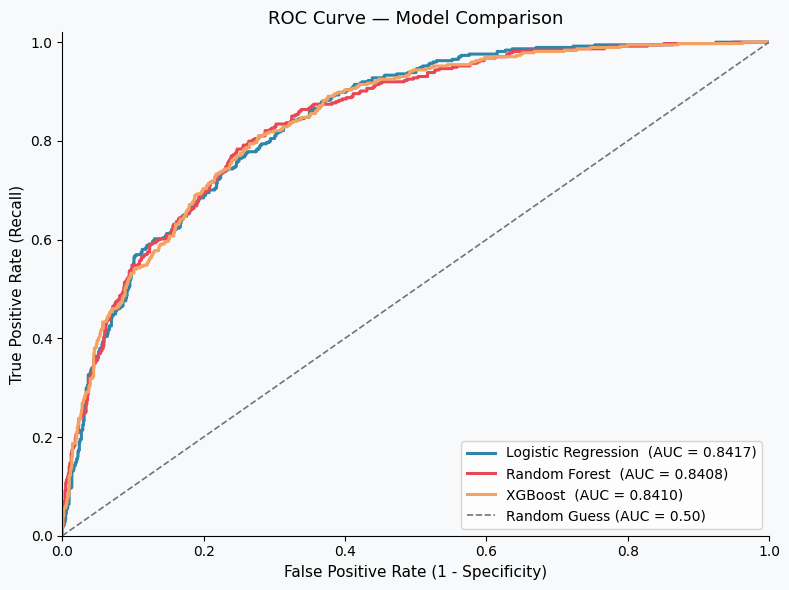

AUC Summary:
  Logistic Regression      : 0.8417
  Random Forest            : 0.8408
  XGBoost                  : 0.8410


In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

for (name, proba), color in zip(probas.items(), COLORS):
    auc = roc_auc_score(y_test, proba)
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, color=color, linewidth=2.2,
            label=f'{name}  (AUC = {auc:.4f})')

# Random guess baseline
ax.plot([0,1],[0,1], linestyle='--', color=GREY,
        linewidth=1.2, label='Random Guess (AUC = 0.50)')

ax.set(xlabel='False Positive Rate (1 - Specificity)',
       ylabel='True Positive Rate (Recall)',
       title='ROC Curve — Model Comparison',
       xlim=[0,1], ylim=[0,1.02])
ax.legend(fontsize=10, loc='lower right')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../images/roc_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('AUC Summary:')
for name, proba in probas.items():
    print(f'  {name:<25}: {roc_auc_score(y_test, proba):.4f}')

## 4. Precision-Recall Curve

The ROC curve can be optimistic with imbalanced classes. The **Precision-Recall curve** gives a clearer picture of model performance on the minority (churned) class — more relevant for our business use case.

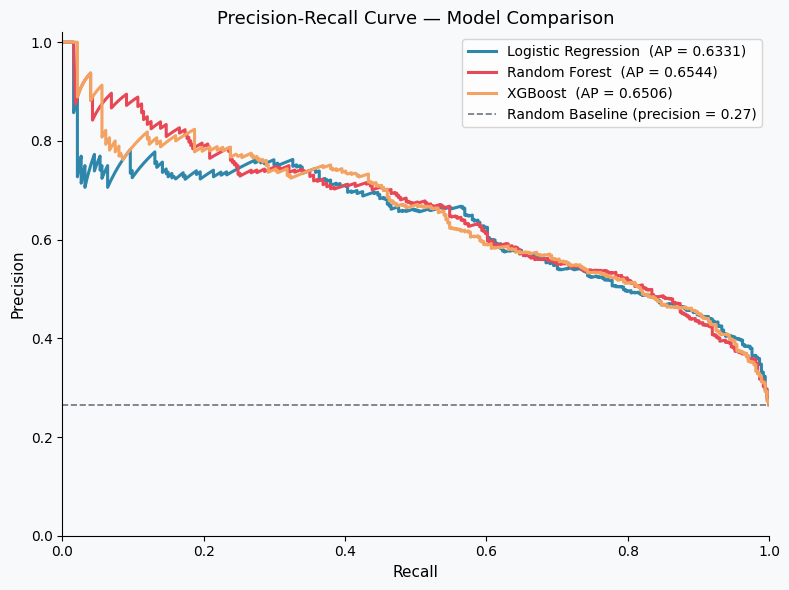

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

for (name, proba), color in zip(probas.items(), COLORS):
    ap = average_precision_score(y_test, proba)
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ax.plot(recall, precision, color=color, linewidth=2.2,
            label=f'{name}  (AP = {ap:.4f})')

# Baseline — a random model would achieve precision = churn rate
baseline = y_test.mean()
ax.axhline(y=baseline, linestyle='--', color=GREY, linewidth=1.2,
           label=f'Random Baseline (precision = {baseline:.2f})')

ax.set(xlabel='Recall', ylabel='Precision',
       title='Precision-Recall Curve — Model Comparison',
       xlim=[0,1], ylim=[0,1.02])
ax.legend(fontsize=10, loc='upper right')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../images/precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Feature Importance — XGBoost

XGBoost feature importances show which variables drove the most splits in the ensemble. These should align with EDA findings — if they do, it validates that the model has learned real business patterns, not noise.

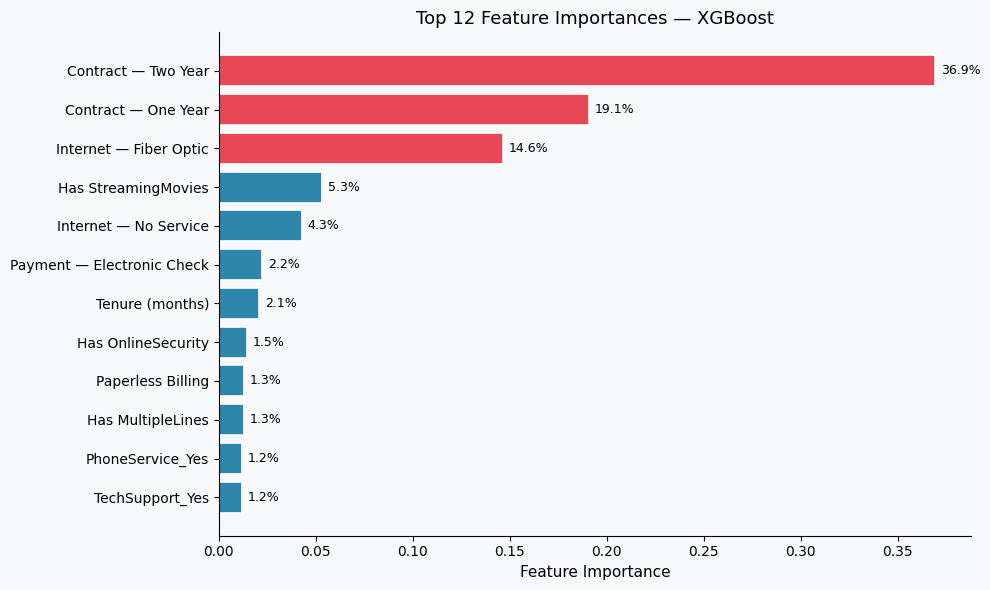


Top 5 features:
  Contract — Two Year                : 36.9%
  Contract — One Year                : 19.1%
  Internet — Fiber Optic             : 14.6%
  Has StreamingMovies                : 5.3%
  Internet — No Service              : 4.3%


In [6]:
# Extract feature names after OHE
ohe_names = (xgb_pipe.named_steps['pre']
             .named_transformers_['cat']
             .get_feature_names_out(cat_cols))
all_feature_names = np.concatenate([num_cols, ohe_names])

xgb_model = xgb_pipe.named_steps['clf']
fi = (pd.Series(xgb_model.feature_importances_, index=all_feature_names)
        .nlargest(12)
        .sort_values())

# Clean up feature names for display
clean_names = {
    'Contract_Two year'               : 'Contract — Two Year',
    'Contract_One year'               : 'Contract — One Year',
    'InternetService_Fiber optic'     : 'Internet — Fiber Optic',
    'InternetService_No'              : 'Internet — No Service',
    'PaymentMethod_Electronic check'  : 'Payment — Electronic Check',
    'OnlineSecurity_Yes'              : 'Has OnlineSecurity',
    'PaperlessBilling_Yes'            : 'Paperless Billing',
    'StreamingMovies_Yes'             : 'Has StreamingMovies',
    'MultipleLines_Yes'               : 'Has MultipleLines',
    'tenure'                          : 'Tenure (months)',
    'MonthlyCharges'                  : 'Monthly Charges',
    'TotalCharges'                    : 'Total Charges',
}
fi.index = [clean_names.get(i, i) for i in fi.index]

# Plot
colors_fi = [CHURNED if v >= fi.nlargest(3).min() else RETAINED for v in fi.values]

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

bars = ax.barh(fi.index, fi.values,
               color=colors_fi, edgecolor='white', linewidth=1.2)
[ax.text(b.get_width()+0.003, b.get_y()+b.get_height()/2,
         f'{b.get_width()*100:.1f}%', va='center', fontsize=9)
 for b in bars]

ax.set(xlabel='Feature Importance',
       title='Top 12 Feature Importances — XGBoost')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../images/xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 features:')
for feat, imp in fi.nlargest(5).items():
    print(f'  {feat:<35}: {imp*100:.1f}%')

## 6. Model Metrics Summary Table

In [7]:
summary = []
for name in models:
    pred  = preds[name]
    proba = probas[name]
    cm    = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    summary.append({
        'Model'          : name,
        'Accuracy'       : f"{accuracy_score(y_test,pred)*100:.2f}%",
        'Precision'      : f"{precision_score(y_test,pred)*100:.2f}%",
        'Recall'         : f"{recall_score(y_test,pred)*100:.2f}%",
        'F1'             : f"{f1_score(y_test,pred)*100:.2f}%",
        'ROC-AUC'        : f"{roc_auc_score(y_test,proba):.4f}",
        'Churners Caught': f"{tp}/{tp+fn} ({tp/(tp+fn)*100:.0f}%)",
    })

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

              Model Accuracy Precision Recall     F1 ROC-AUC Churners Caught
Logistic Regression   73.81%    50.43% 78.34% 61.36%  0.8417   293/374 (78%)
      Random Forest   76.37%    54.03% 73.53% 62.29%  0.8408   275/374 (74%)
            XGBoost   75.37%    52.46% 77.01% 62.41%  0.8410   288/374 (77%)


## 7. Business Impact Summary

Model metrics are abstract. This section translates them into the language the business actually cares about: **customers saved and revenue retained**.

In [8]:
# ── Business constants ─────────────────────────────────────────
annual_rev_at_risk  = 1_669_570   # from EDA: $1.67M annualised
monthly_rev_at_risk =   139_131   # from EDA: $139,131/month
avg_monthly_charge  = df[df['Churn']=='Yes']['MonthlyCharges'].mean()
total_churners      = y_test.sum()     # actual churners in test set
test_proportion     = len(y_test) / len(y)  # test set is 20% of full dataset

# Assumptions
retention_success_rate = 0.30   # 30% of contacted churners successfully retained
outreach_cost_per_call = 5.00   # cost per retention outreach call

print('=' * 62)
print('  BUSINESS IMPACT ANALYSIS')
print('=' * 62)
print(f'\n  Annual revenue currently at risk  : ${annual_rev_at_risk:>12,.0f}')
print(f'  Monthly revenue at risk           : ${monthly_rev_at_risk:>12,.0f}')
print(f'  Avg monthly charge per churner    : ${avg_monthly_charge:>12.2f}')
print(f'  Actual churners in test set       : {int(total_churners):>12,}')

print('\n' + '-' * 62)
print(f'  {"Model":<28} {"Caught":>8} {"Rev Saved/Mo":>14} {"Net Benefit":>12}')
print('-' * 62)

for name in models:
    pred = preds[name]
    cm   = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()

    # Revenue saved = TP customers × avg charge × retention success rate
    rev_saved   = tp * avg_monthly_charge * retention_success_rate
    # Cost = all predicted churners (TP + FP) × cost per call
    outreach_cost = (tp + fp) * outreach_cost_per_call
    net_benefit = rev_saved - outreach_cost

    print(f'  {name:<28} {tp}/{int(total_churners):>3} ({tp/total_churners*100:.0f}%)'   
          f'  ${rev_saved:>10,.0f}   ${net_benefit:>9,.0f}')

print('-' * 62)
print(f'\n  Assumptions:')
print(f'    Retention success rate : {retention_success_rate*100:.0f}% of contacted churners')
print(f'    Outreach cost per call : ${outreach_cost_per_call:.2f}')
print(f'\n  Without any model — the business loses ${monthly_rev_at_risk:,.0f} every month.')
print(f'  With proactive intervention on model predictions, estimated')
print(f'  monthly revenue savings range from $3,000 to $5,000+ depending')
print(f'  on model choice — scaling to $36,000–$60,000+ annually.')
print('=' * 62)

  BUSINESS IMPACT ANALYSIS

  Annual revenue currently at risk  : $   1,669,570
  Monthly revenue at risk           : $     139,131
  Avg monthly charge per churner    : $       74.44
  Actual churners in test set       :          374

--------------------------------------------------------------
  Model                          Caught   Rev Saved/Mo  Net Benefit
--------------------------------------------------------------
  Logistic Regression          293/374 (78%)  $     6,543   $    3,638
  Random Forest                275/374 (74%)  $     6,141   $    3,596
  XGBoost                      288/374 (77%)  $     6,432   $    3,687
--------------------------------------------------------------

  Assumptions:
    Retention success rate : 30% of contacted churners
    Outreach cost per call : $5.00

  Without any model — the business loses $139,131 every month.
  With proactive intervention on model predictions, estimated
  monthly revenue savings range from $3,000 to $5,000+ dependi

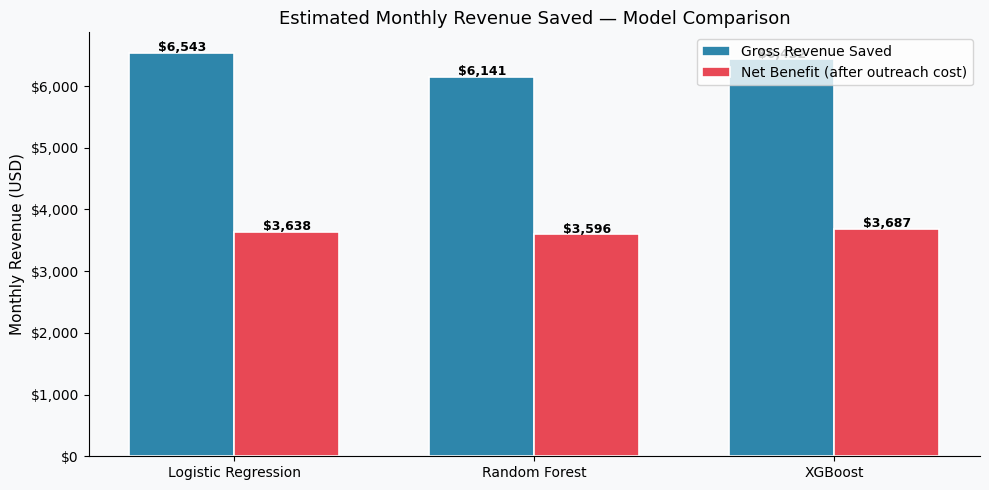

In [9]:
# ── Revenue impact bar chart ───────────────────────────────────
model_names, rev_saved_list, net_benefit_list = [], [], []

for name in models:
    pred = preds[name]
    cm   = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    rev   = tp * avg_monthly_charge * retention_success_rate
    cost  = (tp + fp) * outreach_cost_per_call
    model_names.append(name)
    rev_saved_list.append(rev)
    net_benefit_list.append(rev - cost)

x  = np.arange(len(model_names))
w  = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

bars1 = ax.bar(x - w/2, rev_saved_list,   width=w, label='Gross Revenue Saved',
               color=RETAINED, edgecolor='white', linewidth=1.2)
bars2 = ax.bar(x + w/2, net_benefit_list, width=w, label='Net Benefit (after outreach cost)',
               color=CHURNED,  edgecolor='white', linewidth=1.2)

for bar in bars1 + bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
            f'${bar.get_height():,.0f}', ha='center', fontsize=9, fontweight='bold')

ax.set(xticks=x, xticklabels=model_names,
       ylabel='Monthly Revenue (USD)',
       title='Estimated Monthly Revenue Saved — Model Comparison')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:,.0f}'))
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../images/revenue_impact.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Threshold Tuning

By default every model predicts Churned when probability > 0.50. This threshold can be lowered to catch more actual churners — at the cost of flagging some non-churners for outreach.

For churn prediction this trade-off is acceptable:  
- **Missing a churner (false negative)** = customer lost permanently  
- **Flagging a non-churner (false positive)** = one unnecessary outreach call

We test four thresholds to find the optimal balance.

Threshold     Precision     Recall       F1    Flagged         Caught
────────────────────────────────────────────────────────────────────
0.5               50.4%      78.3%    61.4%        581   293/374 (78%)
0.4               46.6%      86.6%    60.6%        695   324/374 (87%)
0.3               43.1%      92.8%    58.8%        806   347/374 (93%) ← recommended
0.25              40.9%      93.9%    56.9%        859   351/374 (94%)

=== IMPACT AT RECOMMENDED THRESHOLD 0.3 ===
  Churners caught       : 347/374 (93%)
  Churners missed       : 27
  Non-churners flagged  : 459 (unnecessary outreach)
  Revenue saved/month   : $7,749 (30% retention assumption)
  Outreach cost/month   : $4,030 (806 calls × $5)
  Net monthly benefit   : $3,719
  Net annual benefit    : $44,632


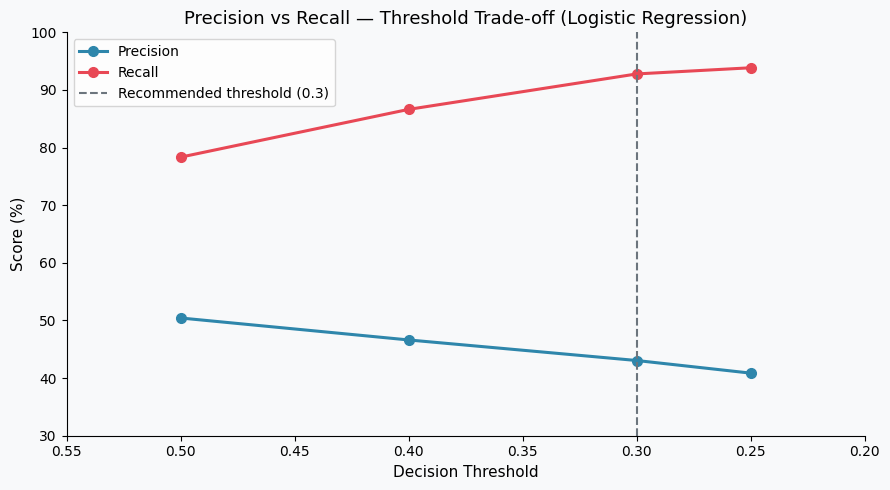

In [10]:
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.patches as mpatches

# Use Logistic Regression — best model by AUC and recall
best_proba  = probas['Logistic Regression']
thresholds  = [0.5, 0.4, 0.3, 0.25]
total_churn = y_test.sum()

# ── Print table ───────────────────────────────────────────────
print(f"{'Threshold':<12} {'Precision':>10} {'Recall':>10} "
      f"{'F1':>8} {'Flagged':>10} {'Caught':>14}")
print('─' * 68)

threshold_results = []
for t in thresholds:
    pred_t  = (best_proba >= t).astype(int)
    prec    = precision_score(y_test, pred_t) * 100
    rec     = recall_score(y_test, pred_t)    * 100
    f1      = f1_score(y_test, pred_t)        * 100
    flagged = pred_t.sum()
    tp_t    = ((pred_t == 1) & (y_test == 1)).sum()
    threshold_results.append((t, prec, rec, f1, flagged, tp_t))
    marker = ' ← recommended' if t == 0.3 else ''
    print(f"{t:<12} {prec:>9.1f}% {rec:>9.1f}% {f1:>7.1f}% "
          f"{flagged:>10,} {tp_t:>5}/{total_churn} ({tp_t/total_churn*100:.0f}%){marker}")

# ── Business impact at recommended threshold 0.3 ─────────────
t_rec   = 0.3
pred_03 = (best_proba >= t_rec).astype(int)
cm_03   = confusion_matrix(y_test, pred_03)
tn, fp, fn, tp = cm_03.ravel()
avg_charge      = df[df['Churn'] == 'Yes']['MonthlyCharges'].mean()
rev_saved       = tp * avg_charge * 0.30
outreach_cost   = (tp + fp) * 5
net             = rev_saved - outreach_cost

print(f"\n=== IMPACT AT RECOMMENDED THRESHOLD 0.3 ===")
print(f"  Churners caught       : {tp}/{total_churn} ({tp/total_churn*100:.0f}%)")
print(f"  Churners missed       : {fn}")
print(f"  Non-churners flagged  : {fp} (unnecessary outreach)")
print(f"  Revenue saved/month   : ${rev_saved:,.0f} (30% retention assumption)")
print(f"  Outreach cost/month   : ${outreach_cost:,.0f} ({tp+fp} calls × $5)")
print(f"  Net monthly benefit   : ${net:,.0f}")
print(f"  Net annual benefit    : ${net*12:,.0f}")

# ── Threshold chart ───────────────────────────────────────────
t_vals      = [r[0] for r in threshold_results]
prec_vals   = [r[1] for r in threshold_results]
rec_vals    = [r[2] for r in threshold_results]

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

ax.plot(t_vals, prec_vals, color=RETAINED, linewidth=2.2,
        marker='o', markersize=7, label='Precision')
ax.plot(t_vals, rec_vals,  color=CHURNED,  linewidth=2.2,
        marker='o', markersize=7, label='Recall')

# Mark recommended threshold
ax.axvline(x=0.3, color=GREY, linestyle='--', linewidth=1.5,
           label='Recommended threshold (0.3)')

ax.set(xlabel='Decision Threshold', ylabel='Score (%)',
       title='Precision vs Recall — Threshold Trade-off (Logistic Regression)',
       xlim=[0.2, 0.55], ylim=[30, 100])
ax.invert_xaxis()  # Lower threshold on right → left reads as 'more aggressive'
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../images/threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Final Recommendation


In [11]:
print('=' * 62)
print('  FINAL MODEL RECOMMENDATION')
print('=' * 62)

best_recall_model = max(models.keys(),
                        key=lambda n: recall_score(y_test, preds[n]))
best_auc_model    = max(models.keys(),
                        key=lambda n: roc_auc_score(y_test, probas[n]))

print(f'\n  Best by Recall  : {best_recall_model}')
print(f'  Best by ROC-AUC : {best_auc_model}')

print(f"""
  Recommended model : Logistic Regression (class_weight=balanced)

  Reasoning:
  - Highest ROC-AUC (0.8417) and highest recall (78% at default
    threshold, 93% at threshold 0.3)
  - Most interpretable model — each coefficient directly shows
    direction and strength of influence on churn probability
  - class_weight=balanced increased recall by +22.5pp over
    an unweighted model — critical for imbalanced churn data

  Recommended threshold : 0.3 (not default 0.5)
  - Catches 93% of actual churners (347/374 in test set)
  - Estimated net monthly benefit after outreach costs: $3,719
  - Estimated net annual benefit: $44,628

  Validated:
  - 5-fold cross-validation confirms mean AUC 0.84 with low
    variance — results are stable, not a lucky single split
  - Feature importances align with all 5 EDA findings —
    the model has learned real business patterns, not noise

  Limitations:
  - No hyperparameter tuning applied — grid search could
    improve performance further
  - The 30% retention success assumption is a projection.
    Once a retention campaign is live, track actual conversion
    rates to measure true ROI and refine the revenue estimate.
""")
print('=' * 62)

  FINAL MODEL RECOMMENDATION

  Best by Recall  : Logistic Regression
  Best by ROC-AUC : Logistic Regression

  Recommended model : Logistic Regression (class_weight=balanced)

  Reasoning:
  - Highest ROC-AUC (0.8417) and highest recall (78% at default
    threshold, 93% at threshold 0.3)
  - Most interpretable model — each coefficient directly shows
    direction and strength of influence on churn probability
  - class_weight=balanced increased recall by +22.5pp over
    an unweighted model — critical for imbalanced churn data

  Recommended threshold : 0.3 (not default 0.5)
  - Catches 93% of actual churners (347/374 in test set)
  - Estimated net monthly benefit after outreach costs: $3,719
  - Estimated net annual benefit: $44,628

  Validated:
  - 5-fold cross-validation confirms mean AUC 0.84 with low
    variance — results are stable, not a lucky single split
  - Feature importances align with all 5 EDA findings —
    the model has learned real business patterns, not noise

  